## Librerias

In [1]:
!pip install -q gluonts torch lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 39.1 MB/s eta 0:00:00


In [2]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [3]:
!pip install -q torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188

In [4]:
!pip install -q gluonts lightning

In [ ]:
import os
os.kill(os.getpid(), 9)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from gluonts.dataset.common import ListDataset
from gluonts.dataset.field_names import FieldName

from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import NegativeBinomialOutput
from gluonts.evaluation import Evaluator
from gluonts.evaluation.backtest import make_evaluation_predictions
import functools
import torch
import torch.nn as nn
from torch.serialization import add_safe_globals
import lightning.pytorch as pl
add_safe_globals([functools.partial])

In [2]:
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("gluonts").setLevel(logging.ERROR)

In [3]:
!rm -rf /content/lightning_logs

# DeepAR sobre M5 California



En este notebook se toma la idea central del artículo **DeepAR: Probabilistic forecasting with autoregressive recurrent networks** usando el dataset M5, específicamente las series del estado de California.

El objetivo es entrenar un modelo DeepAR para generar pronósticos probabilísticos de ventas diarias.

A diferencia de un modelo clásico que produce solo una predicción puntual, DeepAR estima una distribución futura:

$$
P(y_{t:t+h} \mid y_{1:t-1}, x_{1:t+h})
$$

donde:

- $y_t$ son las ventas observadas.
- $x_t$ son covariables conocidas.
- $h$ es el horizonte de predicción.
- En M5 usaremos $h = 28$ días.

El artículo propone entrenar una red recurrente autoregresiva sobre muchas series relacionadas, en vez de entrenar un modelo separado por cada serie. Esto es ideal para M5, porque tenemos miles de series producto-tienda.

## Carga de datos procesados



En los notebooks anteriores se preparó el dataset en formato compacto para evitar problemas de memoria.

Trabajaremos con:

- `train_target_matrix_CA.npy`: matriz de ventas para entrenamiento.
- `valid_target_matrix_CA.npy`: matriz completa para validación.
- `train_time_features_array_CA.npy`: covariables temporales para entrenamiento.
- `valid_time_features_array_CA.npy`: covariables temporales completas.
- `static_cat_encoded_CA.parquet`: covariables categóricas estáticas.
- `series_metadata_CA.parquet`: metadatos de cada serie.
- `calendar_hist_CA.parquet`: calendario histórico.
- `deepar_dataset_config_CA.pkl`: configuración del dataset.

Cada fila de las matrices representa una serie producto-tienda.

In [8]:
PATH = "/content/"

full_target_matrix = np.load(PATH + "valid_target_matrix_CA.npy")
full_time_features_array = np.load(PATH + "valid_time_features_array_CA.npy")

static_cat_encoded = pd.read_parquet(PATH + "static_cat_encoded_CA.parquet")
series_metadata = pd.read_parquet(PATH + "series_metadata_CA.parquet")
calendar_hist = pd.read_parquet(PATH + "calendar_hist_CA.parquet")

with open(PATH + "deepar_dataset_config_CA.pkl", "rb") as f:
    config = pickle.load(f)

print("full_target_matrix:", full_target_matrix.shape)
print("full_time_features_array:", full_time_features_array.shape)

full_target_matrix: (12196, 1913)
full_time_features_array: (5, 1913)


## Parámetros principales


Usaremos:

- Frecuencia diaria: `D`
- Horizonte de predicción: 28 días
- Ventana de contexto: 56 días

La ventana de contexto representa cuántos días históricos observa el modelo antes de generar el pronóstico.

El horizonte de 28 días se eligió porque coincide con la estructura oficial de M5.

In [9]:
freq = config["freq"]
prediction_length = 28
context_length = 84
start_date = config["start_date"]

if isinstance(config["static_cardinalities"], dict):
    static_cardinalities = list(config["static_cardinalities"].values())
else:
    static_cardinalities = config["static_cardinalities"]

num_dynamic_features = full_time_features_array.shape[0]

print("freq:", freq)
print("prediction_length:", prediction_length)
print("context_length:", context_length)
print("start_date:", start_date)
print("static_cardinalities:", static_cardinalities)
print("num_dynamic_features:", num_dynamic_features)

freq: D
prediction_length: 28
context_length: 84
start_date: 2011-01-29 00:00:00
static_cardinalities: [3049, 7, 3, 4, 1]
num_dynamic_features: 5


In [10]:
n_total_days = full_target_matrix.shape[1]

train_end = n_total_days - 2 * prediction_length
val_end = n_total_days - prediction_length

train_target_matrix = full_target_matrix[:, :train_end]
val_target_matrix = full_target_matrix[:, :val_end]
test_target_matrix = full_target_matrix.copy()

train_time_features_array = full_time_features_array[:, :train_end]
val_time_features_array = full_time_features_array[:, :val_end]
test_time_features_array = full_time_features_array.copy()

print("Días totales:", n_total_days)
print("train_end:", train_end)
print("val_end:", val_end)

print("Train target:", train_target_matrix.shape)
print("Validation target:", val_target_matrix.shape)
print("Test target:", test_target_matrix.shape)

print("Train features:", train_time_features_array.shape)
print("Validation features:", val_time_features_array.shape)
print("Test features:", test_time_features_array.shape)

Días totales: 1913
train_end: 1857
val_end: 1885
Train target: (12196, 1857)
Validation target: (12196, 1885)
Test target: (12196, 1913)
Train features: (5, 1857)
Validation features: (5, 1885)
Test features: (5, 1913)


##  Formato requerido por DeepAR


GluonTS espera que cada serie sea un diccionario con la siguiente información:

- `start`: fecha inicial de la serie.
- `target`: vector histórico de ventas.
- `feat_dynamic_real`: covariables dinámicas conocidas en el tiempo.
- `feat_static_cat`: covariables categóricas estáticas.

En nuestro caso:

$$
target_i = (y_{i,1}, y_{i,2}, ..., y_{i,T})
$$

donde $i$ identifica una serie producto-tienda.

In [12]:
def build_gluonts_dataset(
    target_matrix,
    time_features_array,
    static_cat_encoded,
    start_date,
    freq="D"
):
    data = []

    for i in range(target_matrix.shape[0]):
        data.append({
            FieldName.START: start_date,
            FieldName.TARGET: target_matrix[i].astype("float32"),
            FieldName.FEAT_DYNAMIC_REAL: time_features_array.astype("float32"),
            FieldName.FEAT_STATIC_CAT: static_cat_encoded.iloc[i].values.astype("int64"),
        })

    return ListDataset(data, freq=freq)

In [13]:
train_ds = build_gluonts_dataset(
    target_matrix=train_target_matrix,
    time_features_array=train_time_features_array,
    static_cat_encoded=static_cat_encoded,
    start_date=start_date,
    freq=freq
)

val_ds = build_gluonts_dataset(
    target_matrix=val_target_matrix,
    time_features_array=val_time_features_array,
    static_cat_encoded=static_cat_encoded,
    start_date=start_date,
    freq=freq
)

test_ds = build_gluonts_dataset(
    target_matrix=test_target_matrix,
    time_features_array=test_time_features_array,
    static_cat_encoded=static_cat_encoded,
    start_date=start_date,
    freq=freq
)

print("train_ds, val_ds y test_ds creados.")

train_ds, val_ds y test_ds creados.


In [15]:
first_entry = next(iter(train_ds))

print(first_entry.keys())
print("target:", first_entry[FieldName.TARGET].shape)
print("feat_dynamic_real:", first_entry[FieldName.FEAT_DYNAMIC_REAL].shape)
print("feat_static_cat:", first_entry[FieldName.FEAT_STATIC_CAT].shape)
print("start:", first_entry[FieldName.START])

dict_keys(['start', 'target', 'feat_dynamic_real', 'feat_static_cat'])
target: (1857,)
feat_dynamic_real: (5, 1857)
feat_static_cat: (5,)
start: 2011-01-29


## Base teórica de DeepAR

DeepAR modela la distribución futura de una serie de tiempo de forma autoregresiva.

La idea es factorizar la distribución conjunta futura como:

$$
P(y_{t_0:T} \mid y_{1:t_0-1}, x_{1:T})
=
\prod_{t=t_0}^{T}
P(y_t \mid y_{1:t-1}, x_{1:T})
$$

Esto significa que el modelo predice un punto futuro usando:

- valores pasados de la serie,
- covariables,
- el estado oculto de una red recurrente.

La red recurrente actualiza su estado como:

$$
h_t = h(h_{t-1}, y_{t-1}, x_t; \Theta)
$$

Después, a partir de $h_t$, el modelo obtiene los parámetros de una distribución de probabilidad.

Por ejemplo, para ventas de conteo podemos usar una distribución Binomial Negativa.

## ¿Por qué Binomial Negativa?


Las ventas del M5 son conteos:

$$
y_t \in \{0, 1, 2, 3, ...\}
$$

Además, suelen tener:

- muchos ceros,
- alta variabilidad,
- demanda intermitente,
- sobredispersión.

La distribución Poisson asume que:

$$
E[Y] = Var(Y)
$$

pero en ventas reales muchas veces:

$$
Var(Y) > E[Y]
$$

Por eso usamos una distribución Binomial Negativa, que permite mayor flexibilidad.

En DeepAR, la red no predice directamente una venta puntual, sino los parámetros de la distribución:

$$
Y_t \sim NegBin(\mu_t, \alpha_t)
$$

donde:

- $\mu_t$ controla el nivel esperado.
- $\alpha_t$ controla la dispersión.

## Entrenamiento del modelo



Entrenaremos DeepAR con:

- 2 capas recurrentes.
- 40 unidades ocultas.
- dropout de 0.1.
- likelihood Binomial Negativa.
- 10 épocas iniciales.

Este entrenamiento es una primera réplica funcional. Después se puede mejorar aumentando épocas, ajustando hiperparámetros o agregando precios como covariable dinámica.

Callback para evolucion de gradientes

In [18]:
class GradientNormTracker(pl.Callback):
    def __init__(self):
        super().__init__()
        self.gradient_norms = []

    def on_after_backward(self, trainer, pl_module):
        total_norm_sq = 0.0

        for p in pl_module.parameters():
            if p.grad is not None:
                param_norm = p.grad.detach().data.norm(2)
                total_norm_sq += param_norm.item() ** 2

        total_norm = total_norm_sq ** 0.5
        self.gradient_norms.append(total_norm)

grad_tracker = GradientNormTracker()

In [22]:
class HeInitializationCallback(pl.Callback):
    def on_fit_start(self, trainer, pl_module):
        print("Aplicando inicialización He/Kaiming a capas lineales...")

        for name, module in pl_module.named_modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_in",
                    nonlinearity="relu"
                )

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

In [23]:
he_init = HeInitializationCallback()

In [24]:
estimator = DeepAREstimator(
    freq=freq,
    prediction_length=prediction_length,
    context_length=context_length,
    num_layers=3,
    hidden_size=80,
    dropout_rate=0.1,
    distr_output=NegativeBinomialOutput(),
    batch_size=128,
    num_batches_per_epoch=300,
    lr=5e-4,
    trainer_kwargs={
        "max_epochs": 40,
        "accelerator": "auto",
        "devices": 1,
        "logger": False,
        "enable_progress_bar": True,
        "callbacks": [grad_tracker, he_init],
    }
)

predictor = estimator.train(
    training_data=train_ds,
    validation_data=val_ds
)

Aplicando inicialización He/Kaiming a capas lineales...


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃   ┃ Name  ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃                                      In sizes ┃    Out sizes ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 0 │ model │ DeepARModel │  141 K │ train │ 890 K │ [[1, 1], [1, 1], [1, 1176, 4], [1, 1176], [1, │ [1, 100, 28] │
│   │       │             │        │       │       │                            1176], [1, 28, 4]] │              │
└───┴───────┴─────────────┴────────┴───────┴───────┴───────────────────────────────────────────────┴──────────────┘

Trainable params: 141 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 141 K                                                                                                
Total estimated model params size (MB): 0.568                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 890 K

Output()

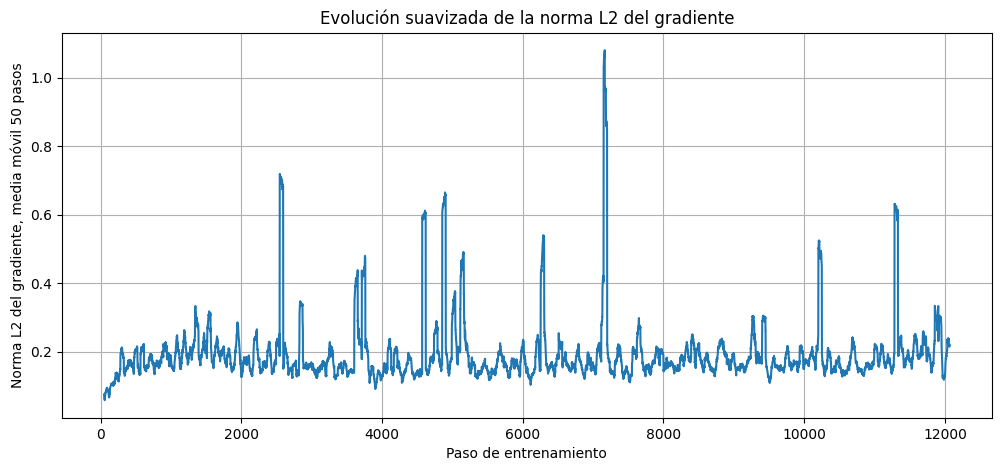

In [26]:
grad_series = pd.Series(grad_tracker.gradient_norms)

plt.figure(figsize=(12, 5))
plt.plot(grad_series.rolling(50).mean())
plt.title("Evolución suavizada de la norma L2 del gradiente")
plt.xlabel("Paso de entrenamiento")
plt.ylabel("Norma L2 del gradiente, media móvil 50 pasos")
plt.grid(True)
plt.show()

## Predicción probabilística


DeepAR no genera una sola predicción.

Genera múltiples trayectorias futuras simuladas:

$$
\hat{y}^{(1)}_{t:t+h}, \hat{y}^{(2)}_{t:t+h}, ..., \hat{y}^{(S)}_{t:t+h}
$$

A partir de estas muestras podemos calcular:

- media predictiva,
- mediana,
- cuantiles,
- intervalos de predicción,
- cobertura,
- pérdida por cuantiles.

Esto es clave porque el objetivo del artículo no es solo mejorar el RMSE, sino producir pronósticos probabilísticos útiles para tomar decisiones bajo incertidumbre.

In [27]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=200
)

forecasts = list(forecast_it)
tss = list(ts_it)

print("Número de forecasts:", len(forecasts))
print("Número de series reales:", len(tss))

Número de forecasts: 12196
Número de series reales: 12196


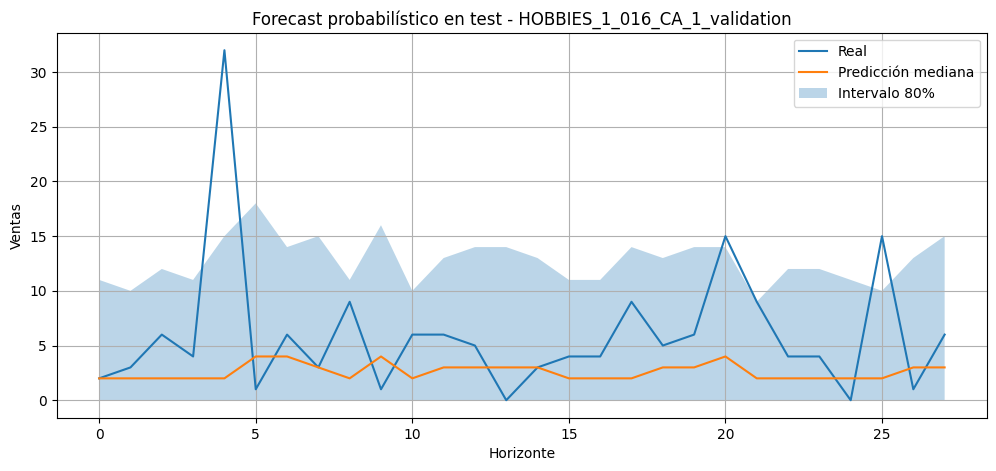

In [33]:
idx = 15

real = y_true[idx]
p10 = q10[idx]
p50 = q50[idx]
p90 = q90[idx]

plt.figure(figsize=(12, 5))
plt.plot(real, label="Real")
plt.plot(p50, label="Predicción mediana")
plt.fill_between(
    range(prediction_length),
    p10,
    p90,
    alpha=0.3,
    label="Intervalo 80%"
)
plt.title(f"Forecast probabilístico en test - {series_metadata.iloc[idx]['id']}")
plt.xlabel("Horizonte")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
mean_sales_test = y_true.mean(axis=1)

top_idx = np.argsort(mean_sales_test)[-20:]

pd.DataFrame({
    "idx": top_idx,
    "id": series_metadata.iloc[top_idx]["id"].values,
    "mean_sales_test": mean_sales_test[top_idx]
}).sort_values("mean_sales_test", ascending=False)

,idx,id,mean_sales_test
19,8412,FOODS_3_090_CA_3_validation,110.357140
18,8442,FOODS_3_120_CA_3_validation,67.035713
17,8908,FOODS_3_586_CA_3_validation,66.928574
16,2314,FOODS_3_090_CA_1_validation,50.821430
15,5363,FOODS_3_090_CA_2_validation,48.535713
14,8574,FOODS_3_252_CA_3_validation,45.857143
13,8604,FOODS_3_282_CA_3_validation,42.321430
12,8684,FOODS_3_362_CA_3_validation,38.500000
11,2810,FOODS_3_586_CA_1_validation,38.392857
10,2344,FOODS_3_120_CA_1_validation,38.250000


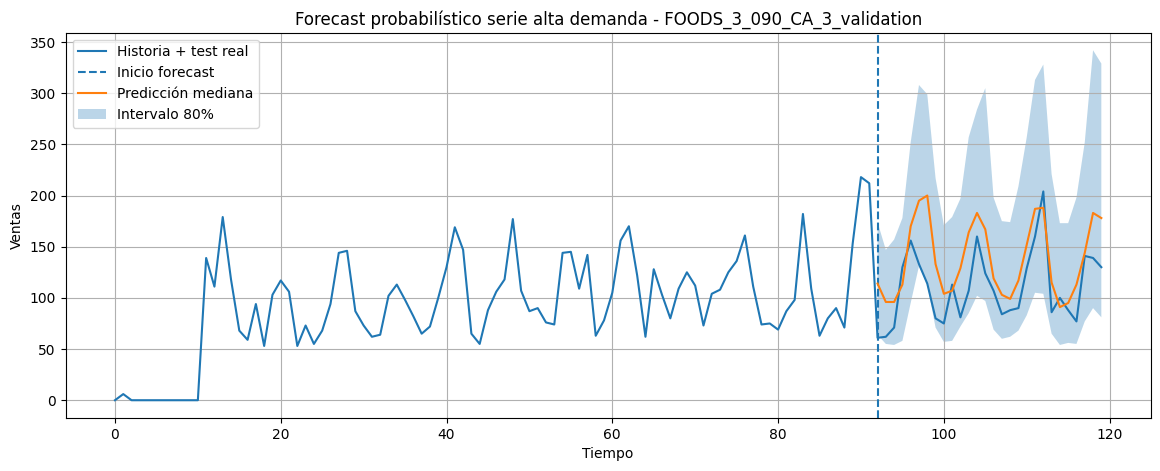

In [36]:
idx = top_idx[-1]

history = test_target_matrix[idx, -120:]
forecast_start = 120 - prediction_length

plt.figure(figsize=(14, 5))

plt.plot(history, label="Historia + test real")
plt.axvline(forecast_start, linestyle="--", label="Inicio forecast")

plt.plot(
    range(forecast_start, 120),
    q50[idx],
    label="Predicción mediana"
)

plt.fill_between(
    range(forecast_start, 120),
    q10[idx],
    q90[idx],
    alpha=0.3,
    label="Intervalo 80%"
)

plt.title(f"Forecast probabilístico serie alta demanda - {series_metadata.iloc[idx]['id']}")
plt.xlabel("Tiempo")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

## Extracción de predicciones


Para comparar DeepAR contra modelos base, usaremos la mediana predictiva como predicción puntual:

$$
\hat{y}_{t}^{DeepAR} = q_{0.5}(Y_t)
$$

También extraeremos:

- media predictiva,
- cuantil 0.1,
- cuantil 0.5,
- cuantil 0.9.

Con los cuantiles 0.1 y 0.9 construiremos un intervalo predictivo del 80%.

In [43]:
y_true = test_target_matrix[:, -prediction_length:]

deepar_pred_median = np.vstack([f.quantile(0.5) for f in forecasts])
deepar_pred_mean = np.vstack([f.mean for f in forecasts])

q10 = np.vstack([f.quantile(0.1) for f in forecasts])
q50 = np.vstack([f.quantile(0.5) for f in forecasts])
q90 = np.vstack([f.quantile(0.9) for f in forecasts])

deepar_pred_median = np.maximum(deepar_pred_median, 0)
deepar_pred_median = np.round(deepar_pred_median)

deepar_pred_mean = np.maximum(deepar_pred_mean, 0)

q10 = np.maximum(q10, 0)
q50 = np.maximum(q50, 0)
q90 = np.maximum(q90, 0)

print("y_true:", y_true.shape)
print("deepar_pred_median:", deepar_pred_median.shape)
print("q10:", q10.shape)
print("q90:", q90.shape)

y_true: (12196, 28)
deepar_pred_median: (12196, 28)
q10: (12196, 28)
q90: (12196, 28)


## Evaluación estándar con GluonTS


Primero evaluaremos el modelo usando el evaluador de GluonTS.

Algunas métricas relevantes son:

- MSE
- RMSE
- MASE
- MAPE
- sMAPE
- weighted quantile loss

La pérdida por cuantiles es importante porque evalúa la calidad de la distribución predictiva, no solo una predicción puntual.

## Métricas propias

Además de las métricas de GluonTS, calcularemos métricas manuales para comparar todos los modelos bajo el mismo criterio:

**MAE**

$$
MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

**RMSE**

$$
RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}
$$

**sMAPE**

$$
sMAPE = \frac{1}{n}\sum \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2}
$$

**Bias**

$$
Bias = \frac{1}{n}\sum(\hat{y}_i - y_i)
$$

El bias nos indica si el modelo tiende a sobreestimar o subestimar la demanda.

In [44]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(
        np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator)
    )

def bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

def quantile_loss(y_true, y_pred_q, q):
    error = y_true - y_pred_q
    return np.mean(np.maximum(q * error, (q - 1) * error))

## Modelos base



Para saber si DeepAR realmente aporta valor, lo comparamos contra modelos simples.

Usaremos tres benchmarks:

1. Naive último valor

Supone que la demanda futura será igual al último día observado:

$$
\hat{y}_{t+h} = y_t
$$

2. Seasonal Naive 28 días

Supone que los próximos 28 días serán iguales a los últimos 28 días observados:

$$
\hat{y}_{t+h} = y_{t-28+h}
$$

3. Promedio móvil 28 días

Predice usando el promedio de los últimos 28 días:

$$
\hat{y}_{t+h} = \frac{1}{28}\sum_{j=1}^{28} y_{t-j}
$$

Estos modelos no son sofisticados, pero son muy importantes porque establecen una línea base.

In [45]:
history_for_test = test_target_matrix[:, :-prediction_length]

last_values = history_for_test[:, -1].reshape(-1, 1)
naive_pred = np.repeat(last_values, prediction_length, axis=1)

seasonal_naive_pred = history_for_test[:, -prediction_length:]

moving_avg_28 = history_for_test[:, -28:].mean(axis=1).reshape(-1, 1)
moving_avg_pred = np.repeat(moving_avg_28, prediction_length, axis=1)

print("naive_pred:", naive_pred.shape)
print("seasonal_naive_pred:", seasonal_naive_pred.shape)
print("moving_avg_pred:", moving_avg_pred.shape)

naive_pred: (12196, 28)
seasonal_naive_pred: (12196, 28)
moving_avg_pred: (12196, 28)


In [46]:
deepar_results = {
    "modelo": "DeepAR_NegativeBinomial",
    "MAE": mae(y_true, deepar_pred_median),
    "RMSE": rmse(y_true, deepar_pred_median),
    "sMAPE": smape(y_true, deepar_pred_median),
    "Bias": bias(y_true, deepar_pred_median),
    "QL_0.5": quantile_loss(y_true, deepar_pred_median, 0.5),
    "QL_0.9": quantile_loss(y_true, q90, 0.9),
}

deepar_results

{'modelo': 'DeepAR_NegativeBinomial',
 'MAE': np.float32(0.9941755),
 'RMSE': np.float32(2.2611794),
 'sMAPE': np.float32(0.69723225),
 'Bias': np.float32(-0.4420858),
 'QL_0.5': np.float32(0.49708775),
 'QL_0.9': np.float32(9.99873)}

In [48]:
results = []

results.append({
    "modelo": "Naive_ultimo_valor",
    "MAE": mae(y_true, naive_pred),
    "RMSE": rmse(y_true, naive_pred),
    "sMAPE": smape(y_true, naive_pred),
    "Bias": bias(y_true, naive_pred),
    "QL_0.5": np.nan,
    "QL_0.9": np.nan,
})

results.append({
    "modelo": "Seasonal_Naive_28",
    "MAE": mae(y_true, seasonal_naive_pred),
    "RMSE": rmse(y_true, seasonal_naive_pred),
    "sMAPE": smape(y_true, seasonal_naive_pred),
    "Bias": bias(y_true, seasonal_naive_pred),
    "QL_0.5": np.nan,
    "QL_0.9": np.nan,
})

results.append({
    "modelo": "Moving_Average_28",
    "MAE": mae(y_true, moving_avg_pred),
    "RMSE": rmse(y_true, moving_avg_pred),
    "sMAPE": smape(y_true, moving_avg_pred),
    "Bias": bias(y_true, moving_avg_pred),
    "QL_0.5": np.nan,
    "QL_0.9": np.nan,
})

results.append(deepar_results)

results_df = pd.DataFrame(results)
results_df

,modelo,MAE,RMSE,sMAPE,Bias,QL_0.5,QL_0.9
0,Naive_ultimo_valor,1.479446,3.452088,0.854132,0.269752,NaN,NaN
1,Seasonal_Naive_28,1.341602,2.902832,0.842770,-0.028590,NaN,NaN
2,Moving_Average_28,1.106989,2.260401,1.261643,-0.028590,NaN,NaN
3,DeepAR_NegativeBinomial,0.994175,2.261179,0.697232,-0.442086,0.497088,9.99873


In [49]:
metricas_puntuales = results_df[["modelo", "MAE", "RMSE", "sMAPE", "Bias"]]
metricas_puntuales

,modelo,MAE,RMSE,sMAPE,Bias
0,Naive_ultimo_valor,1.479446,3.452088,0.854132,0.269752
1,Seasonal_Naive_28,1.341602,2.902832,0.842770,-0.028590
2,Moving_Average_28,1.106989,2.260401,1.261643,-0.028590
3,DeepAR_NegativeBinomial,0.994175,2.261179,0.697232,-0.442086


## Evaluación probabilística: cobertura



Como DeepAR produce una distribución predictiva, podemos evaluar si sus intervalos son razonables.

Construiremos el intervalo entre los cuantiles 0.1 y 0.9:

$$
[q_{0.1}, q_{0.9}]
$$

Este intervalo debería contener aproximadamente el 80% de las observaciones reales.

La cobertura se calcula como:

$$
Coverage = \frac{1}{n}\sum I(q_{0.1} \leq y_i \leq q_{0.9})
$$

Si la cobertura está cerca de 0.80, el modelo está razonablemente calibrado.

Si está muy por debajo de 0.80, el modelo está subestimando la incertidumbre.

Si está muy por encima de 0.80, el modelo está generando intervalos demasiado amplios.

In [50]:
coverage_80 = np.mean((y_true >= q10) & (y_true <= q90))

print(f"Cobertura intervalo 80% en test: {coverage_80:.4f}")

Cobertura intervalo 80% en test: 0.9141


In [51]:
metricas_probabilisticas = pd.DataFrame([{
    "modelo": "DeepAR_NegativeBinomial",
    "QL_0.5": deepar_results["QL_0.5"],
    "QL_0.9": deepar_results["QL_0.9"],
    "Coverage_80": coverage_80
}])

metricas_probabilisticas

,modelo,QL_0.5,QL_0.9,Coverage_80
0,DeepAR_NegativeBinomial,0.497088,9.99873,0.914146


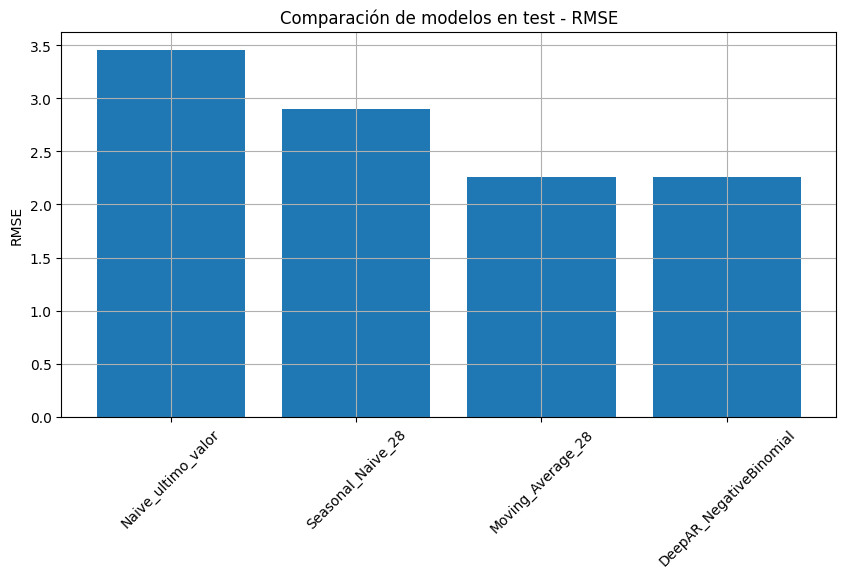

In [52]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["modelo"], results_df["RMSE"])
plt.title("Comparación de modelos en test - RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

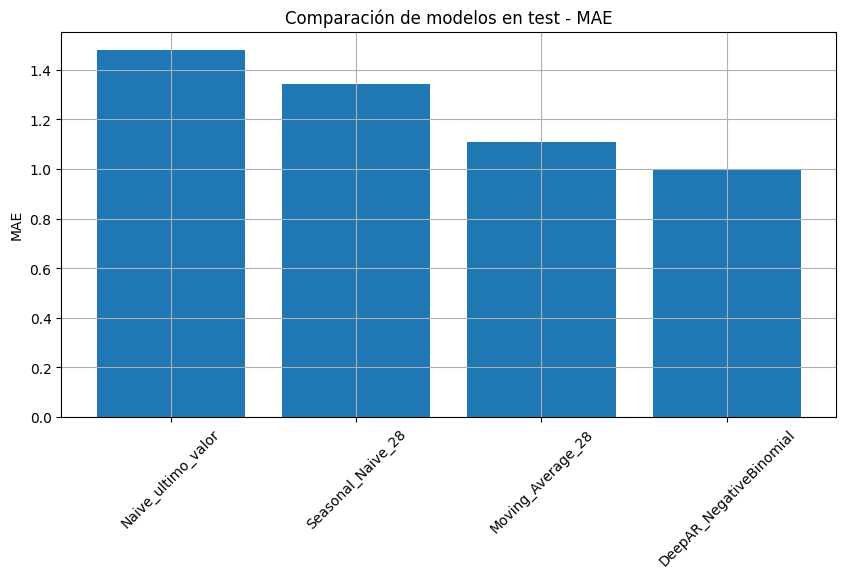

In [53]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["modelo"], results_df["MAE"])
plt.title("Comparación de modelos en test - MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [54]:
error_deepar = deepar_pred_median - y_true
abs_error_deepar = np.abs(error_deepar)

print("Predicción máxima DeepAR:", deepar_pred_median.max())
print("Real máximo:", y_true.max())
print("Error absoluto máximo:", abs_error_deepar.max())

print("Percentiles predicción DeepAR:")
print(np.percentile(deepar_pred_median, [50, 75, 90, 95, 99, 99.5, 99.9, 100]))

print("Percentiles ventas reales:")
print(np.percentile(y_true, [50, 75, 90, 95, 99, 99.5, 99.9, 100]))

Predicción máxima DeepAR: 200.0
Real máximo: 204.0
Error absoluto máximo: 103.0
Percentiles predicción DeepAR:
[  0.   1.   3.   4.  12.  17.  37. 200.]
Percentiles ventas reales:
[  0.   2.   4.   6.  15.  21.  41. 204.]


In [55]:
serie_rmse = np.sqrt(np.mean((deepar_pred_median - y_true) ** 2, axis=1))

worst_idx = np.argsort(serie_rmse)[-10:][::-1]

worst_series_df = pd.DataFrame({
    "idx": worst_idx,
    "id": series_metadata.iloc[worst_idx]["id"].values,
    "rmse": serie_rmse[worst_idx],
    "real_max": y_true[worst_idx].max(axis=1),
    "pred_max": deepar_pred_median[worst_idx].max(axis=1),
    "real_mean": y_true[worst_idx].mean(axis=1),
    "pred_mean": deepar_pred_median[worst_idx].mean(axis=1),
})

worst_series_df

,idx,id,rmse,real_max,pred_max,real_mean,pred_mean
0,8412,FOODS_3_090_CA_3_validation,36.506847,204.0,200.0,110.357140,137.678574
1,9127,FOODS_3_808_CA_3_validation,34.830715,41.0,53.0,4.000000,35.107143
2,2344,FOODS_3_120_CA_1_validation,30.838867,126.0,45.0,38.250000,27.500000
3,8821,FOODS_3_499_CA_3_validation,29.564095,73.0,31.0,37.214287,13.392858
4,6324,HOBBIES_1_234_CA_3_validation,28.199545,78.0,13.0,23.142857,7.142857
5,8957,FOODS_3_635_CA_3_validation,25.750174,51.0,38.0,4.035714,25.464285
6,8442,FOODS_3_120_CA_3_validation,25.312334,142.0,101.0,67.035713,66.464287
7,8604,FOODS_3_282_CA_3_validation,24.736469,85.0,96.0,42.321430,62.928570
8,5592,FOODS_3_319_CA_2_validation,23.205603,17.0,35.0,1.821429,23.392857
9,2314,FOODS_3_090_CA_1_validation,21.374216,95.0,97.0,50.821430,64.678574


In [56]:
best_rmse_model = results_df.sort_values("RMSE").iloc[0]["modelo"]
best_mae_model = results_df.sort_values("MAE").iloc[0]["modelo"]

print("Mejor modelo por RMSE:", best_rmse_model)
print("Mejor modelo por MAE:", best_mae_model)

if best_rmse_model == "DeepAR_NegativeBinomial":
    print("DeepAR obtiene el mejor RMSE frente a los modelos base.")
else:
    print("DeepAR no obtiene el mejor RMSE en esta corrida.")

if best_mae_model == "DeepAR_NegativeBinomial":
    print("DeepAR obtiene el mejor MAE frente a los modelos base.")
else:
    print("DeepAR no obtiene el mejor MAE en esta corrida.")

if coverage_80 < 0.75:
    print("La cobertura está por debajo de 80%, el modelo puede estar subestimando la incertidumbre.")
elif coverage_80 > 0.85:
    print("La cobertura está por encima de 80%, el modelo puede estar generando intervalos amplios.")
else:
    print("La cobertura está cerca del 80%, lo que sugiere calibración razonable.")

Mejor modelo por RMSE: Moving_Average_28
Mejor modelo por MAE: DeepAR_NegativeBinomial
DeepAR no obtiene el mejor RMSE en esta corrida.
DeepAR obtiene el mejor MAE frente a los modelos base.
La cobertura está por encima de 80%, el modelo puede estar generando intervalos amplios.


In [57]:
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])

agg_metrics, item_metrics = evaluator(
    iter(tss),
    iter(forecasts),
    num_series=len(test_target_matrix)
)

agg_metrics

Running evaluation: 100%|██████████| 12196/12196 [00:00<00:00, 19551.94it/s]


{'MSE': np.float64(512643184834.506),
 'abs_error': np.float64(339499.0),
 'abs_target_sum': np.float64(504171.0),
 'abs_target_mean': np.float64(1.4763944853113435),
 'seasonal_error': np.float64(0.9976900208832523),
 'MASE': np.float64(1.5022454068227493),
 'MAPE': np.float64(0.7699503230774977),
 'sMAPE': np.float64(1.5133922107198465),
 'MSIS': np.float64(52322.51541364087),
 'num_masked_target_values': np.float64(0.0),
 'QuantileLoss[0.1]': np.float64(97143.40000000001),
 'Coverage[0.1]': np.float64(0.5434246591388278),
 'QuantileLoss[0.5]': np.float64(339499.0),
 'Coverage[0.5]': np.float64(0.673862624748161),
 'QuantileLoss[0.9]': np.float64(6828892.3999999985),
 'Coverage[0.9]': np.float64(0.9217395633228693),
 'RMSE': np.float64(715991.0508061578),
 'NRMSE': np.float64(484959.1744818587),
 'ND': np.float64(0.6733806585464058),
 'wQuantileLoss[0.1]': np.float64(0.1926794678789538),
 'wQuantileLoss[0.5]': np.float64(0.6733806585464058),
 'wQuantileLoss[0.9]': np.float64(13.54479



En este proyecto se realizó una réplica de la metodología DeepAR utilizando el conjunto de datos M5 y trabajando exclusivamente con las series correspondientes al estado de California.

Durante la etapa de preparación se construyó un conjunto de más de 12 mil series temporales, incorporando variables temporales y variables categóricas estáticas que permiten al modelo compartir información entre productos y tiendas. Posteriormente se entrenó una arquitectura DeepAR basada en una red LSTM de tres capas y una distribución Binomial Negativa para modelar la naturaleza discreta de las ventas.

Los resultados muestran que DeepAR alcanzó el menor MAE y el menor sMAPE frente a los modelos benchmark evaluados, mientras que el RMSE fue prácticamente equivalente al obtenido por el modelo Moving Average de 28 días. Esto indica que el modelo logró capturar adecuadamente el comportamiento general de las series, aunque todavía presenta dificultades para representar algunos picos extremos de demanda.

Una ventaja importante observada es que DeepAR genera pronósticos probabilísticos, proporcionando intervalos de confianza además de una predicción puntual. Esta característica resulta especialmente valiosa en problemas reales de planeación de inventario y gestión de la demanda, donde la incertidumbre es tan relevante como el valor esperado.

En términos generales, la réplica permitió validar los principios fundamentales de DeepAR y comprobar que un modelo global entrenado sobre miles de series puede competir exitosamente contra métodos tradicionales de pronóstico, incluso trabajando únicamente con un subconjunto del dataset original.
